In [129]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

![Task 1](images/task1.png)

In [130]:
data=pd.read_csv('data/sales_data.csv')
data.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [131]:
data.shape

(1000, 14)

In [132]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   str    
 2   Sales_Rep             1000 non-null   str    
 3   Region                1000 non-null   str    
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   str    
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   str    
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   str    
 12  Sales_Channel         1000 non-null   str    
 13  Region_and_Sales_Rep  1000 non-null   str    
dtypes: float64(4), int64(2), str(8)
memory usage: 166.7 KB


In [133]:
data['Sale_Date']=pd.to_datetime(data['Sale_Date'])

In [134]:
data['Month']=data['Sale_Date'].dt.month_name()

In [135]:
data['Month'].unique()

<ArrowStringArray>
[ 'February',     'April', 'September',    'August',     'March',   'January',
      'June',   'October',  'November',  'December',       'May',      'July']
Length: 12, dtype: str

In [136]:
sales_month=data.groupby('Month')['Sales_Amount'].sum()

In [137]:
sales_month

Month
April        438992.61
August       443171.28
December     392643.58
February     368919.36
January      495420.37
July         374242.88
June         418458.34
March        402638.77
May          389078.76
November     467482.90
October      460378.78
September    367837.60
Name: Sales_Amount, dtype: float64

In [138]:
sales_month.index=pd.CategoricalIndex(sales_month.index,categories=['January','February','March','April','May','June','July','August','September','October','November','December'])

In [139]:
sales_month=sales_month.sort_index()

In [140]:
sales_month

Month
January      495420.37
February     368919.36
March        402638.77
April        438992.61
May          389078.76
June         418458.34
July         374242.88
August       443171.28
September    367837.60
October      460378.78
November     467482.90
December     392643.58
Name: Sales_Amount, dtype: float64

In [141]:
#plotting line plot
x=sales_month.index
y=sales_month.values

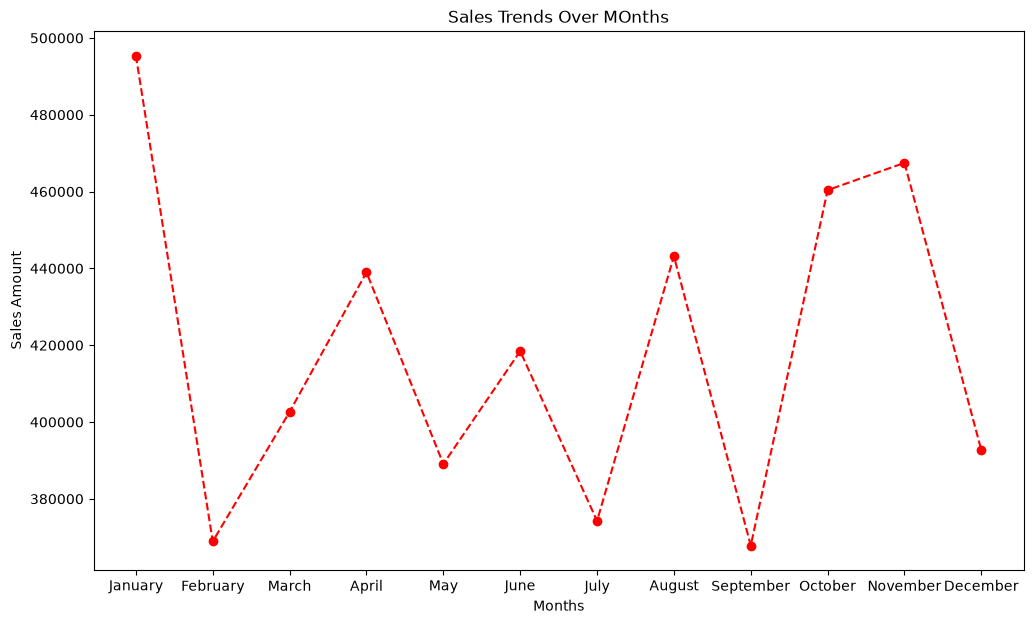

In [142]:
plt.figure(figsize=(12,7))
plt.title('Sales Trends Over MOnths')
plt.xlabel('Months')
plt.ylabel('Sales Amount')
plt.plot(x,y,marker='o',color='red',linestyle='--')
plt.show()

![Task 1](images/task2.png)

In [143]:
data.head(5)

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Month
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,February
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,April
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,September
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,August
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,March


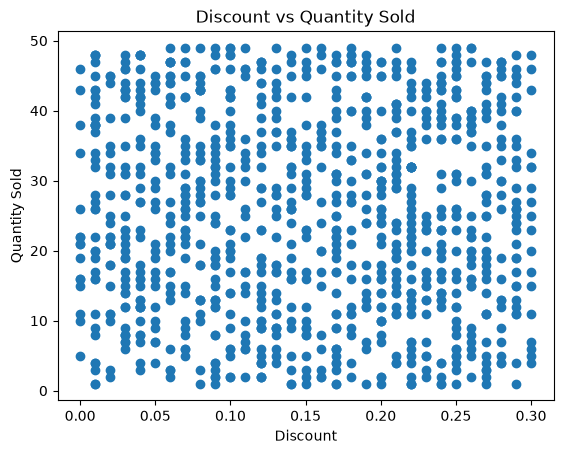

In [147]:
plt.title('Discount vs Quantity Sold')
plt.xlabel('Discount')
plt.ylabel('Quantity Sold')
plt.scatter(data=data,x='Discount',y='Quantity_Sold')

![Task 1](images/task3.png)

In [148]:
data['Sales_Channel'].value_counts()

Sales_Channel
Retail    512
Online    488
Name: count, dtype: int64

In [154]:
count=data.groupby('Sales_Channel')['Product_ID'].count()

In [156]:
x=count.index
y=count.values

/var/folders/c1/6c8s3wn93nd1yg_s50mdh4nc0000gn/T/ipykernel_11638/3747937832.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


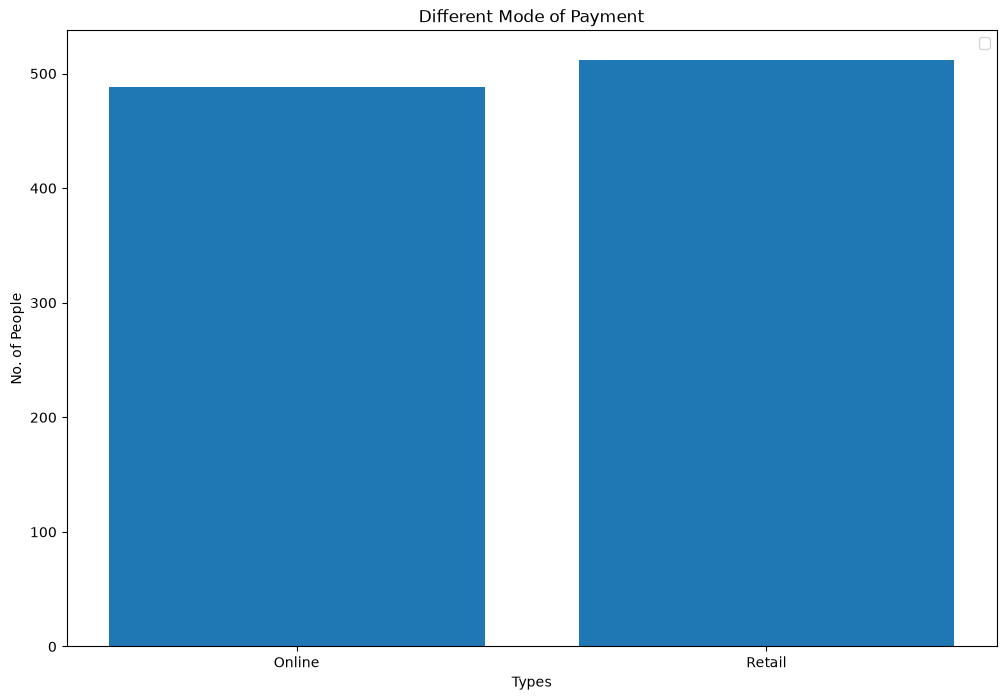

In [167]:
plt.figure(figsize=(12,8))
plt.title('Different Mode of Payment')
plt.xlabel("Types")
plt.ylabel('No. of People')
plt.legend()
plt.bar(x,y)
plt.show()

<BarContainer object of 2 artists>

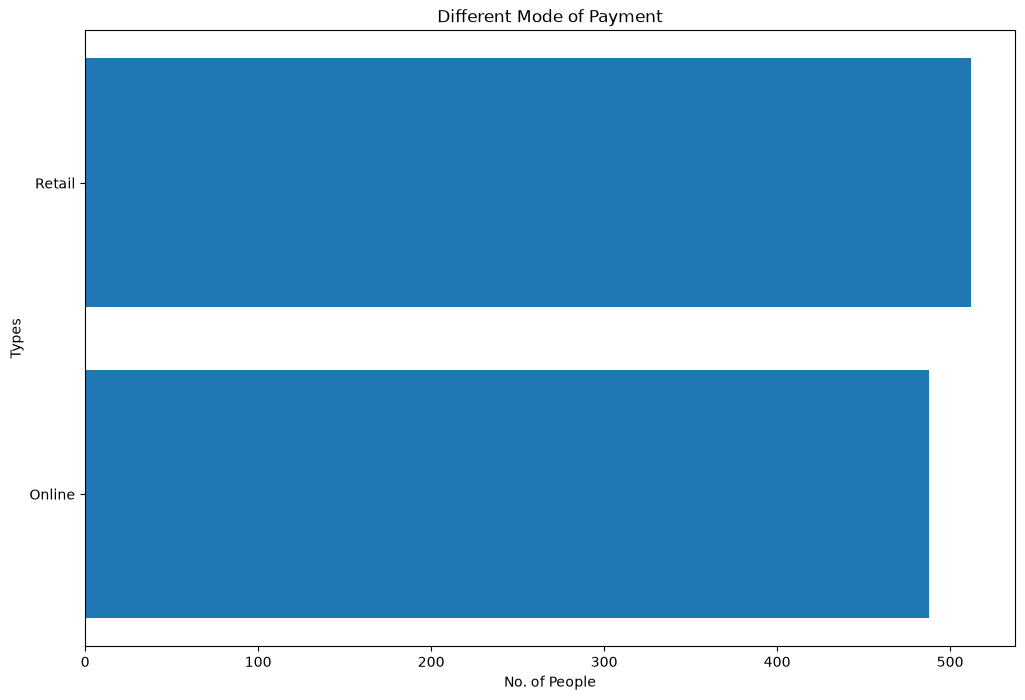

In [169]:
plt.figure(figsize=(12,8))
plt.title('Different Mode of Payment')
plt.ylabel("Types")
plt.xlabel('No. of People')
plt.barh(x,y)

![Task 1](images/task4.png)

In [173]:
data['Year']=data['Sale_Date'].dt.year

In [174]:
data['Year'].value_counts()

Year
2023    997
2024      3
Name: count, dtype: int64

![Task 1](images/task5.png)

![Task 1](images/task6.png)

![Task 1](images/task7.png)